# 11 — Unsupervised Learning
**Goal:** Master clustering, dimensionality reduction, and density
estimation — the three pillars of learning without labels. Source: ISLR
Ch10-12, Murphy Ch21-25.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/learning_courses')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_blobs, make_moons
np.random.seed(11)

## 1. The three problems

Unsupervised learning has no labels. Three sub-problems show up everywhere:

| Problem | Goal | Example |
|---|---|---|
| **Clustering** | group similar points | customer segmentation |
| **Dimensionality reduction** | low-d summary that preserves structure | visualize 10k-d embeddings |
| **Density estimation** | model P(X) | anomaly detection |

The first two are about *finding structure in X*. The third is about
*characterizing the support of X*.

## 2. K-means

**Algorithm (Lloyd 1957):**
1. Initialize K cluster centers μ₁, ..., μ_K (random or k-means++).
2. **Assign** each point to the nearest center.
3. **Update** each center to the mean of its assigned points.
4. Repeat until convergence.

**Objective:** minimize within-cluster sum of squares
    WCSS = Σ_k Σ_{x ∈ Cₖ} ‖x - μₖ‖²

Converges to a *local* minimum. k-means++ initialization (Arthur &
Vassilvitskii 2007) makes bad local minima much rarer.

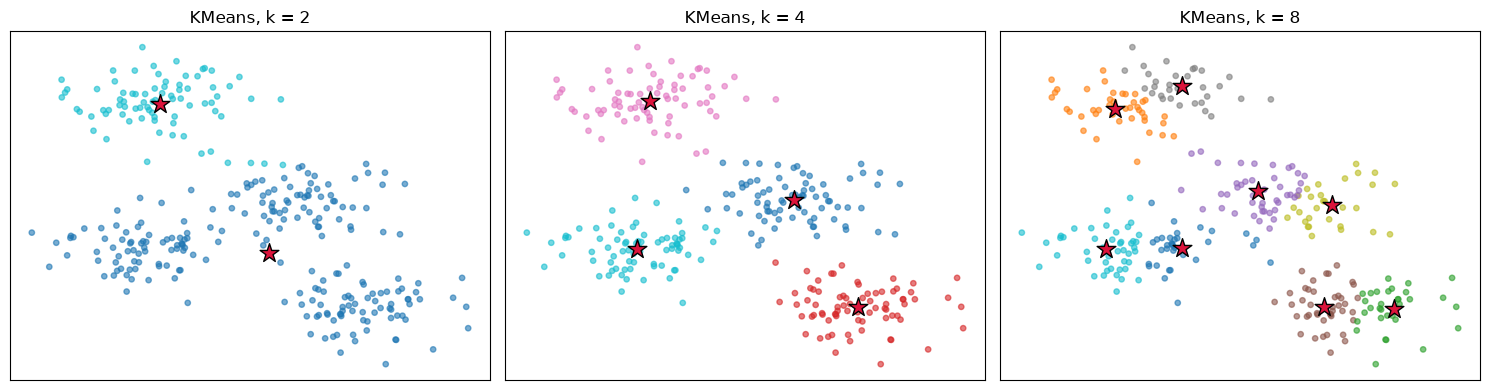

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.7, random_state=0)
for ax, k in zip(axes, [2, 4, 8]):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    ax.scatter(*X.T, c=km.labels_, cmap='tab10', s=15, alpha=0.6)
    ax.scatter(*km.cluster_centers_.T, marker='*', s=200, c='crimson', edgecolor='k')
    ax.set_title(f'KMeans, k = {k}'); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 3. Choosing K — the elbow and the silhouette

**Elbow:** plot WCSS vs K; the bend is the natural K. Subjective.
**Silhouette:** for each point, (b - a) / max(a, b) where a is the mean
distance to its cluster mates and b to the next-closest cluster. Mean
silhouette in [-1, 1]; higher is better. More objective than the elbow.

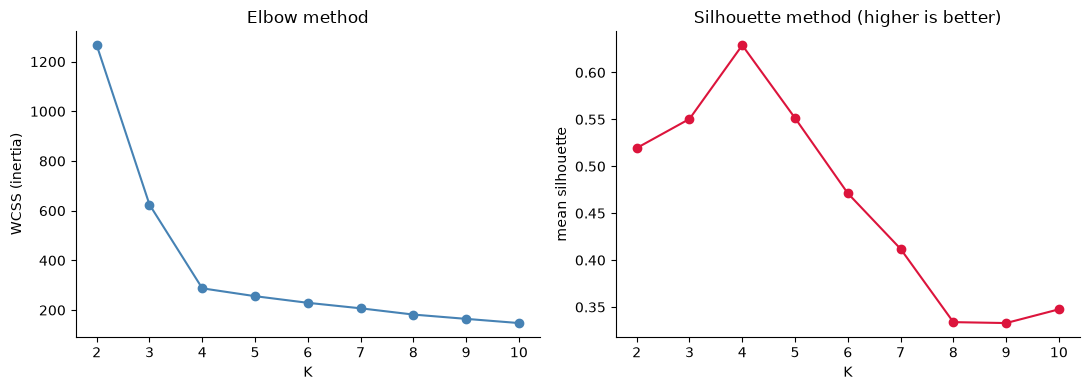

In [3]:
from sklearn.metrics import silhouette_score
Ks = list(range(2, 11))
wcss, sil = [], []
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(Ks, wcss, marker='o', color='steelblue')
ax[0].set_xlabel('K'); ax[0].set_ylabel('WCSS (inertia)')
ax[0].set_title('Elbow method')
ax[0].spines[['top','right']].set_visible(False)
ax[1].plot(Ks, sil, marker='o', color='crimson')
ax[1].set_xlabel('K'); ax[1].set_ylabel('mean silhouette')
ax[1].set_title('Silhouette method (higher is better)')
ax[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 4. Hierarchical clustering

**Agglomerative (bottom-up):** start with n singletons, repeatedly merge the
two closest clusters. The result is a tree (dendrogram) you can cut at any
level to get K clusters.

**Linkage criteria:**
- **Single**   : min distance between points in the two clusters.
- **Complete** : max distance.
- **Average**  : mean distance.
- **Ward**     : minimize within-cluster variance after the merge.

Single linkage chains; complete linkage prefers compact clusters. Ward is the
default in sklearn and usually the best.

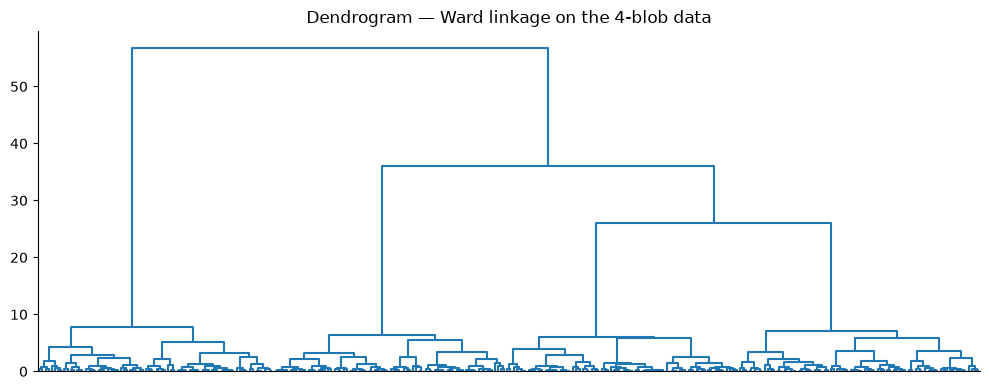

In [4]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(X, method='ward')
fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(Z, ax=ax, no_labels=True, color_threshold=0)
ax.set_title('Dendrogram — Ward linkage on the 4-blob data')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 5. DBSCAN — density-based, finds non-convex shapes

DBSCAN groups points that are densely packed together and marks as outliers
those that lie alone in low-density regions. Two parameters:
- **eps** — neighborhood radius.
- **min_samples** — minimum points to be a core point.

**Core point:** at least min_samples points within eps. **Border point:**
within eps of a core point but not a core point itself. **Noise:** neither.

Unlike K-means, DBSCAN can find arbitrarily shaped clusters and explicitly
marks outliers — perfect for anomaly detection.

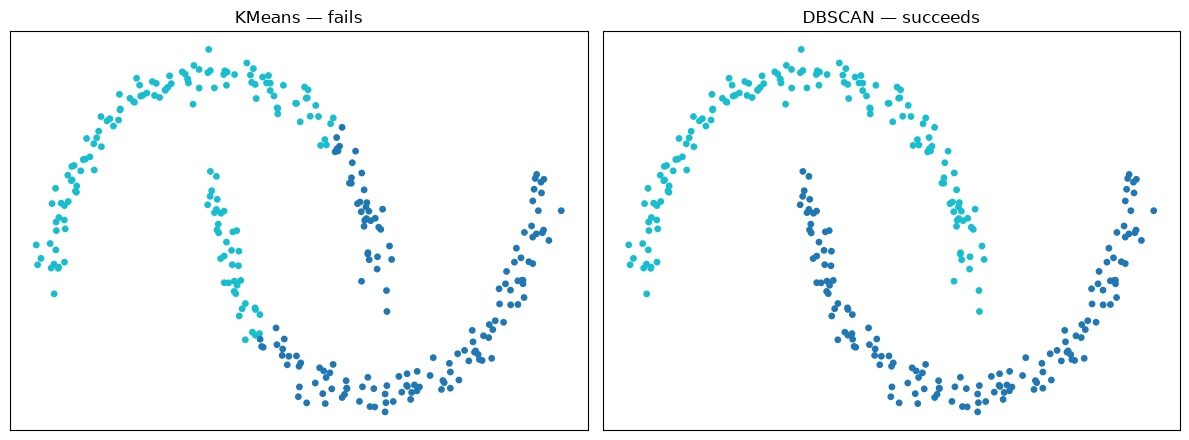

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
X, _ = make_moons(n_samples=300, noise=0.05, random_state=0)
km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(X)
db = DBSCAN(eps=0.2, min_samples=5).fit(X)
axes[0].scatter(*X.T, c=km.labels_, cmap='tab10', s=15); axes[0].set_title('KMeans — fails')
axes[1].scatter(*X.T, c=db.labels_, cmap='tab10', s=15); axes[1].set_title('DBSCAN — succeeds')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 6. Principal Component Analysis (PCA)

PCA finds the orthogonal directions of **maximum variance** in X and
projects onto the top k of them. Three equivalent views:

1. **Geometric** — the principal components are the right singular vectors
   of the centered data matrix X.
2. **Algebraic** — eigenvectors of the covariance matrix Σ = X⊤X / n.
3. **Reconstruction** — PCA is the best rank-k linear approximation in
   Frobenius norm.

**Properties:**
- Uncorrelated components.
- First component explains the most variance, second the next-most
  (orthogonal to the first), etc.
- Sensitive to scaling — always standardize features first.

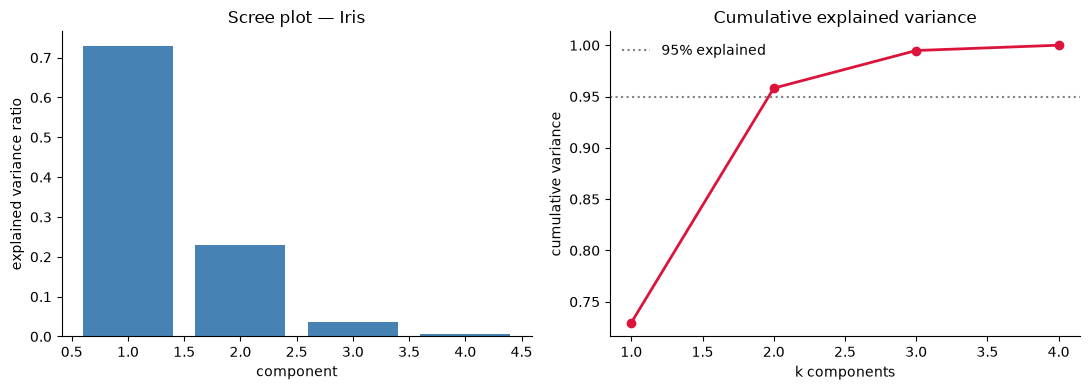

In [6]:
from sklearn.datasets import load_iris
X = load_iris().data
X_std = StandardScaler().fit_transform(X)
pca = PCA().fit(X_std)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(range(1, 5), pca.explained_variance_ratio_, color='steelblue')
axes[0].set_xlabel('component'); axes[0].set_ylabel('explained variance ratio')
axes[0].set_title('Scree plot — Iris')
axes[0].spines[['top','right']].set_visible(False)
cum = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, 5), cum, marker='o', color='crimson', lw=2)
axes[1].axhline(0.95, color='gray', linestyle=':', label='95% explained')
axes[1].set_xlabel('k components'); axes[1].set_ylabel('cumulative variance')
axes[1].set_title('Cumulative explained variance')
axes[1].legend(frameon=False); axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 7. PCA for visualization

Reducing to 2 or 3 components is the most common way to make a high-d dataset
plottable. It is **linear** — non-linear structure is missed.

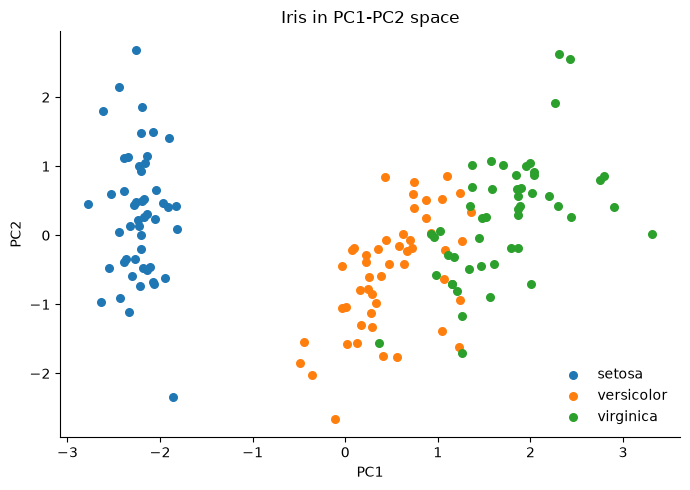

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
X2 = pca.transform(X_std)[:, :2]
y = load_iris().target
for c in np.unique(y):
    ax.scatter(X2[y == c, 0], X2[y == c, 1], s=30, label=load_iris().target_names[c])
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Iris in PC1-PC2 space')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 8. t-SNE and UMAP — non-linear embeddings

PCA cannot unroll a curved manifold. **t-SNE** (van der Maaten & Hinton
2008) and **UMAP** (McInnes et al. 2018) preserve *local* neighborhoods in
2D/3D. They are great for visualization but not for downstream ML — use the
original features for modeling.

Caveats (Distill 2016, Wattenberg et al.):
- Cluster sizes in t-SNE/UMAP are not meaningful.
- Distances between clusters are not meaningful.
- **Always** run with several `random_state` and `perplexity` and report a
  range of plots.

/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_56051/3267184418.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


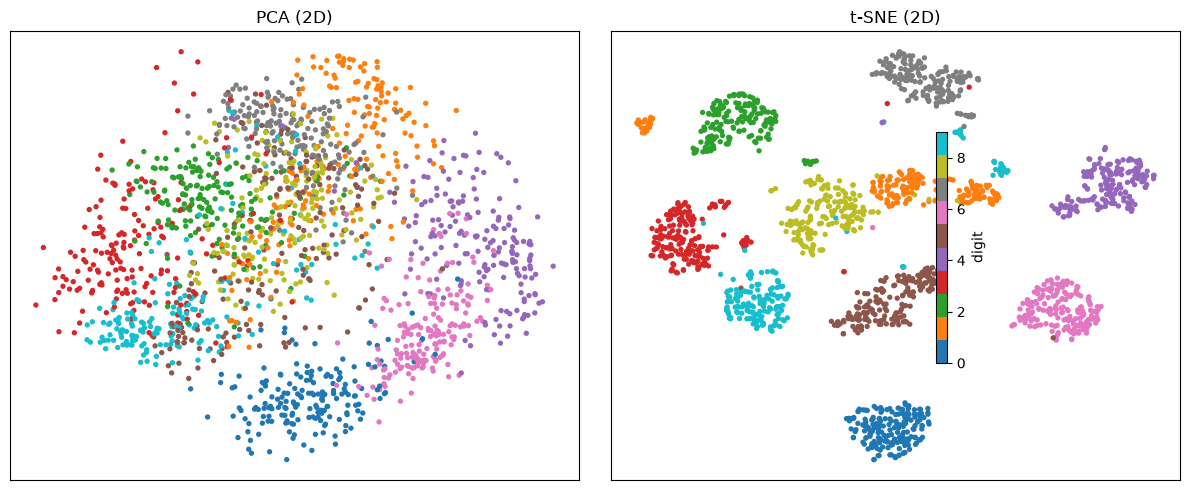

In [8]:
from sklearn.datasets import load_digits
digits = load_digits()
X, y = digits.data, digits.target
pca2 = PCA(n_components=2).fit_transform(X)
tsne2 = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(X)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, emb, name in zip(axes, [pca2, tsne2], ['PCA (2D)', 't-SNE (2D)']):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap='tab10', s=8)
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(sc, ax=axes, shrink=0.6, label='digit')
plt.tight_layout(); plt.show()

## 9. Anomaly detection

Three classical approaches:

1. **Density-based** — fit a model of P(X) (e.g. Gaussian mixture), flag
   points with low P(X). sklearn: `GaussianMixture`.
2. **Distance-based** — flag points whose distance to the k-th nearest
   neighbor is large.
3. **One-class SVM** — learns a tight boundary around the data; points
   outside are anomalies. sklearn: `OneClassSVM`.
4. **Isolation Forest** — anomalies are easy to isolate with random splits.
   sklearn: `IsolationForest`.

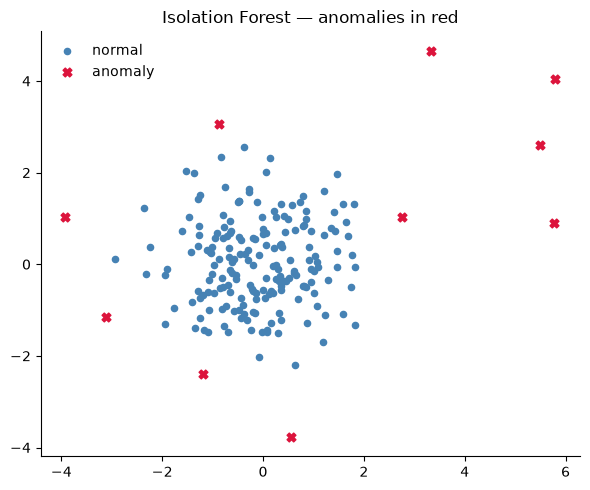

In [9]:
from sklearn.ensemble import IsolationForest
rng = np.random.default_rng(0)
X = rng.normal(0, 1, (200, 2))
X[:5] = rng.uniform(-6, 6, (5, 2))   # inject 5 outliers
iso = IsolationForest(contamination=0.05, random_state=0).fit(X)
labels = iso.predict(X)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[labels ==  1, 0], X[labels ==  1, 1], s=20, color='steelblue', label='normal')
ax.scatter(X[labels == -1, 0], X[labels == -1, 1], s=40, color='crimson', label='anomaly', marker='X')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
ax.set_title('Isolation Forest — anomalies in red')
plt.tight_layout(); plt.show()

## 10. Practical guidance

- **Always scale** before K-means, PCA, t-SNE, DBSCAN.
- **Try multiple K** for K-means; report silhouette.
- **Ward linkage** is the safe default for hierarchical clustering.
- **DBSCAN** when clusters have weird shapes or you want outlier labels.
- **PCA** for linear structure and feature engineering.
- **t-SNE / UMAP** for visualization only — not for downstream models.
- **k-means vs DBSCAN vs hierarchical:**
  - k-means: fast, convex clusters, needs K
  - DBSCAN: slow, arbitrary shapes, finds K, marks outliers
  - hierarchical: O(n²) memory, gives the full tree of clusterings

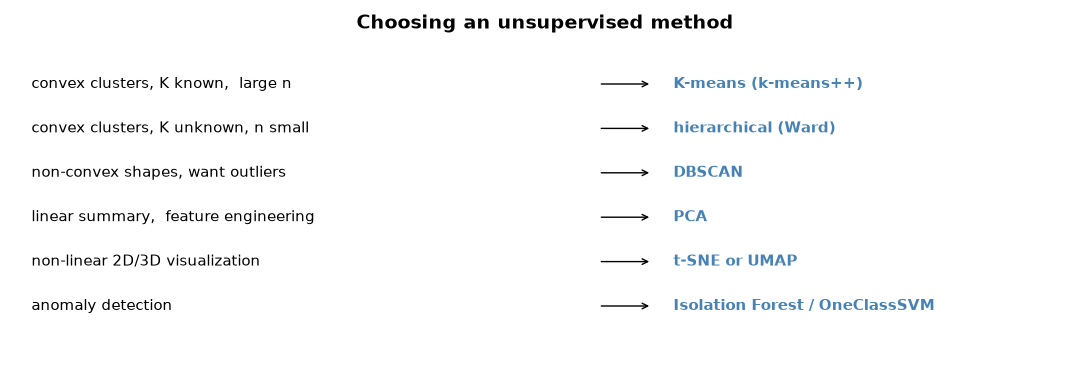

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.axis('off')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.text(0.5, 0.95, 'Choosing an unsupervised method',
        ha='center', fontsize=14, weight='bold')
rows = [
    ('convex clusters, K known,  large n',  'K-means (k-means++)'),
    ('convex clusters, K unknown, n small', 'hierarchical (Ward)'),
    ('non-convex shapes, want outliers',    'DBSCAN'),
    ('linear summary,  feature engineering','PCA'),
    ('non-linear 2D/3D visualization',     't-SNE or UMAP'),
    ('anomaly detection',                  'Isolation Forest / OneClassSVM'),
]
for i, (q, c) in enumerate(rows):
    y = 0.8 - i * 0.12
    ax.text(0.02, y, q, fontsize=11, va='center')
    ax.annotate('', xy=(0.6, y), xytext=(0.55, y), arrowprops=dict(arrowstyle='->'))
    ax.text(0.62, y, c, fontsize=11, va='center', color='steelblue', weight='bold')
plt.tight_layout(); plt.show()

## Summary

| Method | Finds | Needs |
|---|---|---|
| K-means | convex clusters | K |
| Hierarchical | nested clusters | linkage |
| DBSCAN | arbitrary shapes + outliers | eps, min_samples |
| PCA | linear low-d summary | number of components |
| t-SNE / UMAP | non-linear 2D/3D layout | perplexity / n_neighbors |
| Isolation Forest | anomalies | contamination |

**Next:** `12_neural_networks.ipynb` — from linear to deep.